In [70]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [71]:
df=pd.read_excel('ICRISAT Weather 1978 to 2018.xlsx')

In [72]:
df.head()

,Station,Date,MaxT,MinT,RH1,RH2,Wind,Rain,SSH,Evap,Radiation,FAO56_ET,Lat,Lon,Cum_Rain
0,ICRISAT,1978-01-01,28.5,14.2,68,31.0,5.7,0.0,10.1,4.3,18.4,3.9,17.508409,78.2723,0.0
1,ICRISAT,1978-01-02,28.8,16.0,79,33.0,6.4,0.0,9.8,4.8,16.9,3.9,17.508409,78.2723,0.0
2,ICRISAT,1978-01-03,29.0,14.5,86,37.0,5.4,0.0,9.1,4.6,15.3,3.4,17.508409,78.2723,0.0
3,ICRISAT,1978-01-04,29.0,18.0,89,43.0,7.1,0.0,9.0,4.2,16.4,3.8,17.508409,78.2723,0.0
4,ICRISAT,1978-01-05,27.8,17.0,81,47.0,10.5,0.0,8.9,4.3,15.9,4.1,17.508409,78.2723,0.0


In [73]:
df[df.isnull().any(axis=1)]

,Station,Date,MaxT,MinT,RH1,RH2,Wind,Rain,SSH,Evap,Radiation,FAO56_ET,Lat,Lon,Cum_Rain
14410,ICRISAT,2017-06-15,30.0,24.0,86,74.0,5.8,0.0,0.0,1.7,NaN,2.5,17.508409,78.2723,109.8


In [74]:
df.shape

(14853, 15)

In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14853 entries, 0 to 14852
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Station    14853 non-null  str           
 1   Date       14853 non-null  datetime64[us]
 2   MaxT       14853 non-null  float64       
 3   MinT       14853 non-null  float64       
 4   RH1        14853 non-null  int64         
 5   RH2        14853 non-null  float64       
 6   Wind       14853 non-null  float64       
 7   Rain       14853 non-null  float64       
 8   SSH        14853 non-null  float64       
 9   Evap       14853 non-null  float64       
 10  Radiation  14852 non-null  float64       
 11  FAO56_ET   14853 non-null  float64       
 12  Lat        14853 non-null  float64       
 13  Lon        14853 non-null  float64       
 14  Cum_Rain   14853 non-null  float64       
dtypes: datetime64[us](1), float64(12), int64(1), str(1)
memory usage: 1.7 MB


In [76]:
df = df.dropna()

In [77]:
df[df.isnull().any(axis=True)]

,Station,Date,MaxT,MinT,RH1,RH2,Wind,Rain,SSH,Evap,Radiation,FAO56_ET,Lat,Lon,Cum_Rain


In [78]:
for i in df.columns:
    print(i," : ",df[i].unique())

Station  :  <StringArray>
['ICRISAT']
Length: 1, dtype: str
Date  :  <DatetimeArray>
['1978-01-01 00:00:00', '1978-01-02 00:00:00', '1978-01-03 00:00:00',
 '1978-01-04 00:00:00', '1978-01-05 00:00:00', '1978-01-06 00:00:00',
 '1978-01-07 00:00:00', '1978-01-08 00:00:00', '1978-01-09 00:00:00',
 '1978-01-10 00:00:00',
 ...
 '2018-08-22 00:00:00', '2018-08-23 00:00:00', '2018-08-24 00:00:00',
 '2018-08-25 00:00:00', '2018-08-26 00:00:00', '2018-08-27 00:00:00',
 '2018-08-28 00:00:00', '2018-08-29 00:00:00', '2018-08-30 00:00:00',
 '2018-08-31 00:00:00']
Length: 14852, dtype: datetime64[us]
MaxT  :  [28.5 28.8 29.  27.8 27.2 26.5 26.8 28.2 23.5 23.7 25.4 26.3 28.  27.9
 29.1 29.4 29.6 29.8 29.3 27.7 28.9 27.6 29.2 29.9 30.4 28.7 30.7 31.8
 31.6 32.8 31.7 33.  32.5 27.1 30.3 31.4 31.2 32.4 33.7 33.6 34.8 34.1
 33.5 34.5 34.4 32.3 35.9 35.2 34.6 35.  36.2 37.  36.  36.7 36.9 36.4
 37.5 37.2 37.7 36.1 34.3 35.4 36.8 38.1 38.6 40.5 40.3 40.8 41.1 39.7
 37.9 38.  39.3 38.5 32.6 35.1 38.3 39.  

In [79]:
df['Date']=pd.to_datetime(df['Date'])
df['Month']=df['Date'].dt.month
df['Year']=df['Date'].dt.year
df['Day'] = df['Date'].dt.day
df.drop('Date', axis=1, inplace=True)

In [80]:
df = df.sort_values(by=['Year', 'Month', 'Day'])
df = df.reset_index(drop=True)

In [81]:
# df['Month']=df['Date'].dt.month

In [82]:
# df.drop('Date',axis=1,inplace=True)

In [83]:
df.drop('Station',axis=1,inplace=True)

In [84]:
df.head()

,MaxT,MinT,RH1,RH2,Wind,Rain,SSH,Evap,Radiation,FAO56_ET,Lat,Lon,Cum_Rain,Month,Year,Day
0,28.5,14.2,68,31.0,5.7,0.0,10.1,4.3,18.4,3.9,17.508409,78.2723,0.0,1,1978,1
1,28.8,16.0,79,33.0,6.4,0.0,9.8,4.8,16.9,3.9,17.508409,78.2723,0.0,1,1978,2
2,29.0,14.5,86,37.0,5.4,0.0,9.1,4.6,15.3,3.4,17.508409,78.2723,0.0,1,1978,3
3,29.0,18.0,89,43.0,7.1,0.0,9.0,4.2,16.4,3.8,17.508409,78.2723,0.0,1,1978,4
4,27.8,17.0,81,47.0,10.5,0.0,8.9,4.3,15.9,4.1,17.508409,78.2723,0.0,1,1978,5


In [85]:
df['RainTomorrow']=(df['Rain'].shift(-1)>0).astype(int)
df['Rain_lag1'] = df['Rain'].shift(1) #past
df['Rain_lag2'] = df['Rain'].shift(2) 

In [86]:
df['Rain']

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
14847     4.5
14848    13.2
14849    14.0
14850     0.0
14851     0.0
Name: Rain, Length: 14852, dtype: float64

In [87]:
# plt.plot(df['Cum_Rain'])

In [88]:
# df[['Month' ,'Rain', 'Cum_Rain']].head(50)
y=[int(i) for i in df['Year'].unique()]
print(y)



[1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]


In [89]:
visy={}
for i in y:
    visy[i]=0
visy 
vism={}
m=[1,2,3,4,5,6,7,8,9,10,11,12]

In [90]:
for i in range(df.shape[0]):
    if df.iloc[i]['Month']==1 and visy[df.iloc[i]['Year']]==0 and df.iloc[i]['Day']==1:
        print(df.iloc[i]['Cum_Rain']," ",df.iloc[i]['Year']," ",df.iloc[i]['Month']," ",df.iloc[i]['Day'])
        visy[df.iloc[i]['Year']]=1


0.0   1978.0   1.0   1.0
0.0   1979.0   1.0   1.0
0.0   1980.0   1.0   1.0
0.0   1981.0   1.0   1.0
0.0   1982.0   1.0   1.0
0.0   1983.0   1.0   1.0
0.0   1984.0   1.0   1.0
0.0   1985.0   1.0   1.0
0.0   1986.0   1.0   1.0
0.0   1987.0   1.0   1.0
0.0   1988.0   1.0   1.0
0.0   1989.0   1.0   1.0
9.6   1990.0   1.0   1.0
16.2   1991.0   1.0   1.0
0.0   1992.0   1.0   1.0
0.0   1993.0   1.0   1.0
0.0   1994.0   1.0   1.0
0.0   1995.0   1.0   1.0
0.0   1996.0   1.0   1.0
0.0   1997.0   1.0   1.0
0.0   1998.0   1.0   1.0
0.0   1999.0   1.0   1.0
0.0   2000.0   1.0   1.0
14.2   2001.0   1.0   1.0
0.0   2002.0   1.0   1.0
0.0   2003.0   1.0   1.0
0.0   2004.0   1.0   1.0
0.0   2005.0   1.0   1.0
0.0   2006.0   1.0   1.0
0.0   2007.0   1.0   1.0
0.0   2008.0   1.0   1.0
0.0   2009.0   1.0   1.0
0.0   2010.0   1.0   1.0
0.0   2011.0   1.0   1.0
0.0   2012.0   1.0   1.0
0.0   2013.0   1.0   1.0
0.0   2014.0   1.0   1.0
0.0   2015.0   1.0   1.0
0.0   2016.0   1.0   1.0
0.0   2017.0   1.0   1.

In [91]:
df['Rain_3days'] = df['Rain'].rolling(3).sum()
df['Rain_7days'] = df['Rain'].rolling(7).sum()  

In [92]:
df

,MaxT,MinT,RH1,RH2,Wind,Rain,SSH,Evap,Radiation,FAO56_ET,...,Lon,Cum_Rain,Month,Year,Day,RainTomorrow,Rain_lag1,Rain_lag2,Rain_3days,Rain_7days
0,28.5,14.2,68,31.0,5.7,0.0,10.1,4.3,18.4,3.9,...,78.2723,0.0,1,1978,1,0,NaN,NaN,NaN,NaN
1,28.8,16.0,79,33.0,6.4,0.0,9.8,4.8,16.9,3.9,...,78.2723,0.0,1,1978,2,0,0.0,NaN,NaN,NaN
2,29.0,14.5,86,37.0,5.4,0.0,9.1,4.6,15.3,3.4,...,78.2723,0.0,1,1978,3,0,0.0,0.0,0.0,NaN
3,29.0,18.0,89,43.0,7.1,0.0,9.0,4.2,16.4,3.8,...,78.2723,0.0,1,1978,4,0,0.0,0.0,0.0,NaN
4,27.8,17.0,81,47.0,10.5,0.0,8.9,4.3,15.9,4.1,...,78.2723,0.0,1,1978,5,0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14847,29.5,22.2,93,64.0,9.6,4.5,1.4,2.5,12.9,3.5,...,78.2723,1493.2,8,2018,27,1,0.0,0.0,4.5,14.1
14848,29.2,22.6,90,70.0,9.2,13.2,0.4,4.7,11.7,3.2,...,78.2723,1506.4,8,2018,28,1,4.5,0.0,17.7,17.7
14849,29.6,22.4,91,63.0,7.6,14.0,2.9,3.6,15.0,3.7,...,78.2723,1520.4,8,2018,29,0,13.2,4.5,31.7,31.7
14850,30.6,23.0,87,59.0,8.2,0.0,9.8,5.2,19.7,4.7,...,78.2723,1520.4,8,2018,30,0,14.0,13.2,27.2,31.7


In [93]:
df[df.isnull().any(axis=1)]

,MaxT,MinT,RH1,RH2,Wind,Rain,SSH,Evap,Radiation,FAO56_ET,...,Lon,Cum_Rain,Month,Year,Day,RainTomorrow,Rain_lag1,Rain_lag2,Rain_3days,Rain_7days
0,28.5,14.2,68,31.0,5.7,0.0,10.1,4.3,18.4,3.9,...,78.2723,0.0,1,1978,1,0,NaN,NaN,NaN,NaN
1,28.8,16.0,79,33.0,6.4,0.0,9.8,4.8,16.9,3.9,...,78.2723,0.0,1,1978,2,0,0.0,NaN,NaN,NaN
2,29.0,14.5,86,37.0,5.4,0.0,9.1,4.6,15.3,3.4,...,78.2723,0.0,1,1978,3,0,0.0,0.0,0.0,NaN
3,29.0,18.0,89,43.0,7.1,0.0,9.0,4.2,16.4,3.8,...,78.2723,0.0,1,1978,4,0,0.0,0.0,0.0,NaN
4,27.8,17.0,81,47.0,10.5,0.0,8.9,4.3,15.9,4.1,...,78.2723,0.0,1,1978,5,0,0.0,0.0,0.0,NaN
5,27.2,19.4,86,49.0,13.5,0.0,9.5,5.1,13.8,4.0,...,78.2723,0.0,1,1978,6,0,0.0,0.0,0.0,NaN


In [94]:
df.dropna(inplace=True)

In [95]:
df

,MaxT,MinT,RH1,RH2,Wind,Rain,SSH,Evap,Radiation,FAO56_ET,...,Lon,Cum_Rain,Month,Year,Day,RainTomorrow,Rain_lag1,Rain_lag2,Rain_3days,Rain_7days
6,26.5,19.5,85,46.0,11.4,0.0,5.4,4.7,13.0,3.8,...,78.2723,0.0,1,1978,7,1,0.0,0.0,0.0,0.0
7,27.2,18.5,92,51.0,11.7,16.5,5.0,4.2,14.2,3.7,...,78.2723,16.5,1,1978,8,0,0.0,0.0,16.5,16.5
8,26.8,18.5,90,47.0,12.0,0.0,7.7,3.6,13.4,3.8,...,78.2723,16.5,1,1978,9,1,16.5,0.0,16.5,16.5
9,28.2,19.5,91,71.0,11.9,0.7,5.4,3.4,11.8,3.0,...,78.2723,17.2,1,1978,10,0,0.0,16.5,17.2,17.2
10,23.5,14.6,95,55.0,5.9,0.0,4.2,2.6,13.1,2.6,...,78.2723,17.2,1,1978,11,0,0.7,0.0,0.7,17.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14847,29.5,22.2,93,64.0,9.6,4.5,1.4,2.5,12.9,3.5,...,78.2723,1493.2,8,2018,27,1,0.0,0.0,4.5,14.1
14848,29.2,22.6,90,70.0,9.2,13.2,0.4,4.7,11.7,3.2,...,78.2723,1506.4,8,2018,28,1,4.5,0.0,17.7,17.7
14849,29.6,22.4,91,63.0,7.6,14.0,2.9,3.6,15.0,3.7,...,78.2723,1520.4,8,2018,29,0,13.2,4.5,31.7,31.7
14850,30.6,23.0,87,59.0,8.2,0.0,9.8,5.2,19.7,4.7,...,78.2723,1520.4,8,2018,30,0,14.0,13.2,27.2,31.7


In [96]:
df.drop(columns=['Rain'],inplace=True)

In [97]:
df.head()

,MaxT,MinT,RH1,RH2,Wind,SSH,Evap,Radiation,FAO56_ET,Lat,Lon,Cum_Rain,Month,Year,Day,RainTomorrow,Rain_lag1,Rain_lag2,Rain_3days,Rain_7days
6,26.5,19.5,85,46.0,11.4,5.4,4.7,13.0,3.8,17.508409,78.2723,0.0,1,1978,7,1,0.0,0.0,0.0,0.0
7,27.2,18.5,92,51.0,11.7,5.0,4.2,14.2,3.7,17.508409,78.2723,16.5,1,1978,8,0,0.0,0.0,16.5,16.5
8,26.8,18.5,90,47.0,12.0,7.7,3.6,13.4,3.8,17.508409,78.2723,16.5,1,1978,9,1,16.5,0.0,16.5,16.5
9,28.2,19.5,91,71.0,11.9,5.4,3.4,11.8,3.0,17.508409,78.2723,17.2,1,1978,10,0,0.0,16.5,17.2,17.2
10,23.5,14.6,95,55.0,5.9,4.2,2.6,13.1,2.6,17.508409,78.2723,17.2,1,1978,11,0,0.7,0.0,0.7,17.2


In [98]:
y=df['RainTomorrow']
x=df.drop(columns=['RainTomorrow'])

In [99]:
x=x.drop(columns=['Cum_Rain','Lat','Lon'])

In [100]:
x

,MaxT,MinT,RH1,RH2,Wind,SSH,Evap,Radiation,FAO56_ET,Month,Year,Day,Rain_lag1,Rain_lag2,Rain_3days,Rain_7days
6,26.5,19.5,85,46.0,11.4,5.4,4.7,13.0,3.8,1,1978,7,0.0,0.0,0.0,0.0
7,27.2,18.5,92,51.0,11.7,5.0,4.2,14.2,3.7,1,1978,8,0.0,0.0,16.5,16.5
8,26.8,18.5,90,47.0,12.0,7.7,3.6,13.4,3.8,1,1978,9,16.5,0.0,16.5,16.5
9,28.2,19.5,91,71.0,11.9,5.4,3.4,11.8,3.0,1,1978,10,0.0,16.5,17.2,17.2
10,23.5,14.6,95,55.0,5.9,4.2,2.6,13.1,2.6,1,1978,11,0.7,0.0,0.7,17.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14847,29.5,22.2,93,64.0,9.6,1.4,2.5,12.9,3.5,8,2018,27,0.0,0.0,4.5,14.1
14848,29.2,22.6,90,70.0,9.2,0.4,4.7,11.7,3.2,8,2018,28,4.5,0.0,17.7,17.7
14849,29.6,22.4,91,63.0,7.6,2.9,3.6,15.0,3.7,8,2018,29,13.2,4.5,31.7,31.7
14850,30.6,23.0,87,59.0,8.2,9.8,5.2,19.7,4.7,8,2018,30,14.0,13.2,27.2,31.7


In [101]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 14846 entries, 6 to 14851
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MaxT        14846 non-null  float64
 1   MinT        14846 non-null  float64
 2   RH1         14846 non-null  int64  
 3   RH2         14846 non-null  float64
 4   Wind        14846 non-null  float64
 5   SSH         14846 non-null  float64
 6   Evap        14846 non-null  float64
 7   Radiation   14846 non-null  float64
 8   FAO56_ET    14846 non-null  float64
 9   Month       14846 non-null  int32  
 10  Year        14846 non-null  int32  
 11  Day         14846 non-null  int32  
 12  Rain_lag1   14846 non-null  float64
 13  Rain_lag2   14846 non-null  float64
 14  Rain_3days  14846 non-null  float64
 15  Rain_7days  14846 non-null  float64
dtypes: float64(12), int32(3), int64(1)
memory usage: 1.6 MB


In [102]:
x.corr()

,MaxT,MinT,RH1,RH2,Wind,SSH,Evap,Radiation,FAO56_ET,Month,Year,Day,Rain_lag1,Rain_lag2,Rain_3days,Rain_7days
MaxT,1.000000,0.536837,-0.736906,-0.600919,0.129682,0.415155,0.876438,0.670815,0.867475,-0.392066,0.051049,0.003773,-0.210007,-0.158192,-0.248573,-0.265057
MinT,0.536837,1.000000,-0.328197,0.224581,0.490528,-0.291267,0.421547,0.133341,0.505142,-0.068292,-0.049506,-0.003061,0.118717,0.119111,0.159065,0.219693
RH1,-0.736906,-0.328197,1.000000,0.604190,-0.115554,-0.362652,-0.777881,-0.546431,-0.730221,0.378855,0.111310,-0.002453,0.166797,0.146740,0.249021,0.275313
RH2,-0.600919,0.224581,0.604190,1.000000,0.214635,-0.756745,-0.642531,-0.688909,-0.607835,0.401535,0.059537,-0.004840,0.381192,0.310629,0.501094,0.557293
Wind,0.129682,0.490528,-0.115554,0.214635,1.000000,-0.305911,0.314991,-0.054083,0.400132,-0.120754,-0.264939,-0.003446,0.100251,0.102532,0.150429,0.197660
SSH,0.415155,-0.291267,-0.362652,-0.756745,-0.305911,1.000000,0.481486,0.744337,0.457699,-0.225302,-0.090102,0.013112,-0.336578,-0.256009,-0.442716,-0.453005
Evap,0.876438,0.421547,-0.777881,-0.642531,0.314991,0.481486,1.000000,0.686335,0.928329,-0.411983,-0.117040,0.003789,-0.230212,-0.183047,-0.280847,-0.310759
Radiation,0.670815,0.133341,-0.546431,-0.688909,-0.054083,0.744337,0.686335,1.000000,0.773056,-0.280134,-0.131101,0.009064,-0.277787,-0.175192,-0.359155,-0.325750
FAO56_ET,0.867475,0.505142,-0.730221,-0.607835,0.400132,0.457699,0.928329,0.773056,1.000000,-0.385964,-0.168801,0.000939,-0.219258,-0.147039,-0.273257,-0.262043
Month,-0.392066,-0.068292,0.378855,0.401535,-0.120754,-0.225302,-0.411983,-0.280134,-0.385964,1.000000,-0.017426,0.009714,0.082081,0.083779,0.117626,0.164209


In [103]:
corr_matrix = x.corr().abs()
l=set()
col=corr_matrix.columns
for i in range(len(corr_matrix.columns)):
    for j in range (i):
        if(corr_matrix.iloc[i,j]>0.9):
            l.add(col[i])
l

{'FAO56_ET'}

<Axes: >

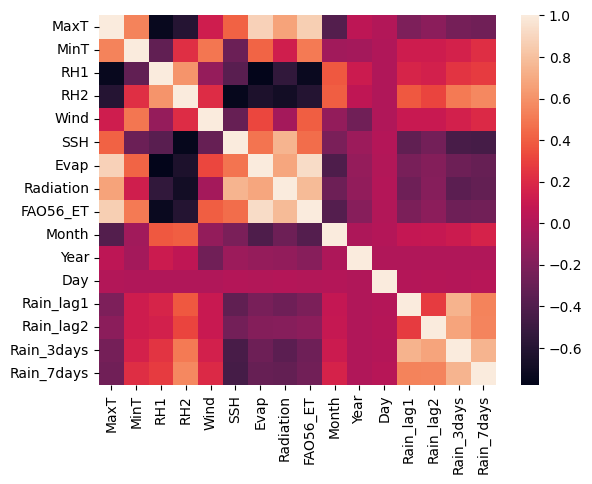

In [104]:
sns.heatmap(x.corr())

In [105]:
x=x.drop(columns=l)

<Axes: >

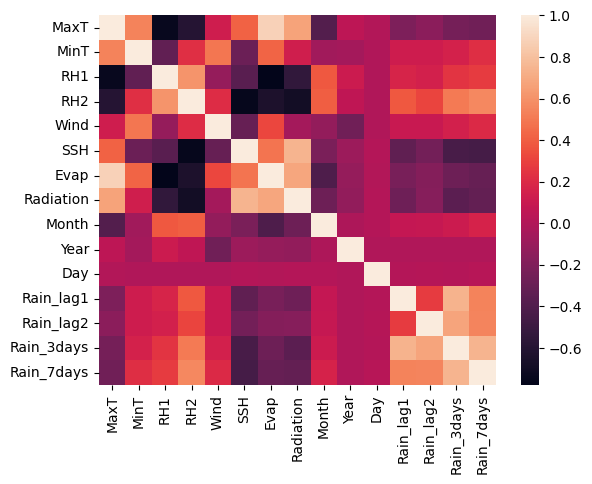

In [106]:
sns.heatmap(x.corr())

In [107]:
# from sklearn.model_selection import train_test_split
# x_test,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.25)

In [108]:
print(df.isnull().sum())

MaxT            0
MinT            0
RH1             0
RH2             0
Wind            0
SSH             0
Evap            0
Radiation       0
FAO56_ET        0
Lat             0
Lon             0
Cum_Rain        0
Month           0
Year            0
Day             0
RainTomorrow    0
Rain_lag1       0
Rain_lag2       0
Rain_3days      0
Rain_7days      0
dtype: int64


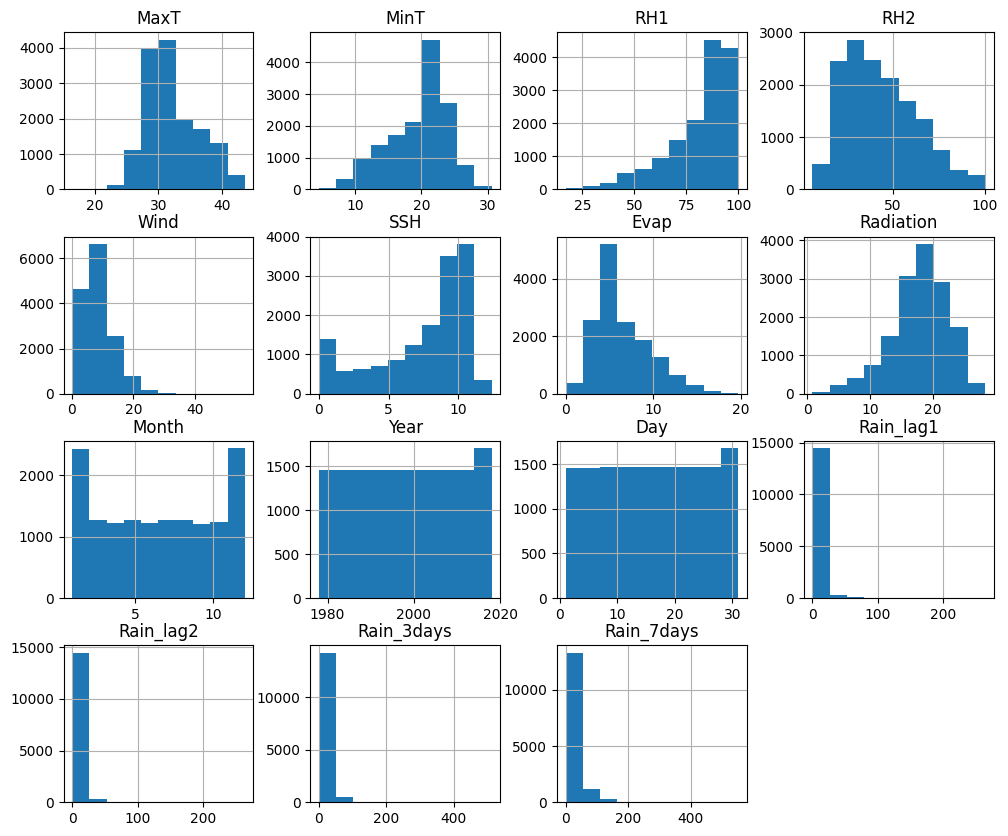

In [109]:
x.hist(figsize=(12,10))
plt.show()

In [110]:
# for handeling the values near to zero
df['Rain_3days'] = np.log1p(df['Rain_3days'])
df['Rain_7days'] = np.log1p(df['Rain_7days'])

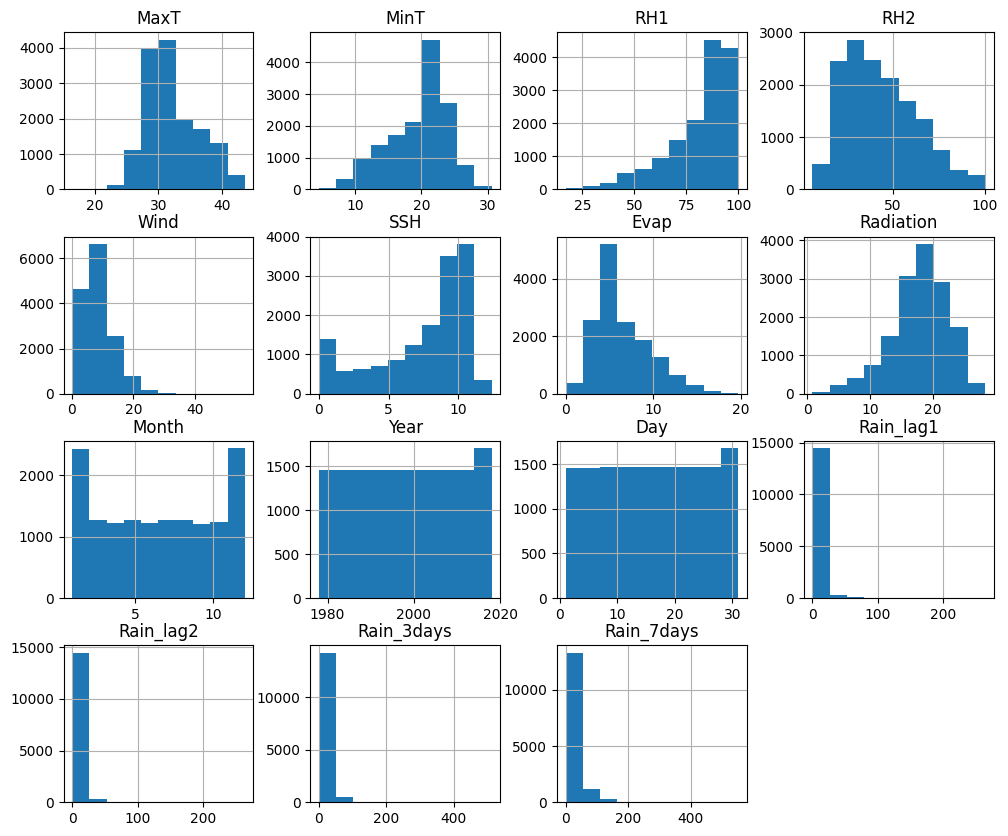

In [111]:
x.hist(figsize=(12,10))
plt.show()

In [112]:
df['Humidity_avg'] = (df['RH1'] + df['RH2']) / 2

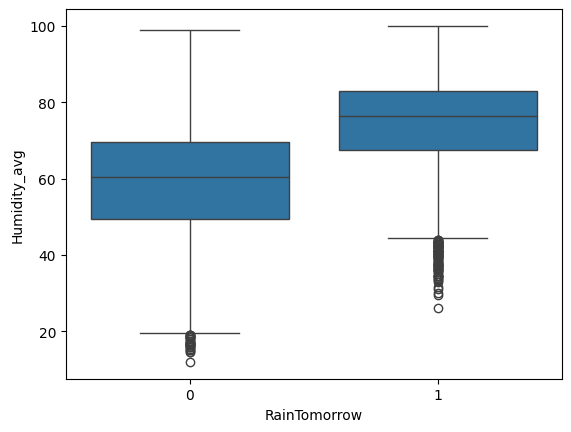

In [113]:
sns.boxplot(x=y, y=df['Humidity_avg'])
plt.show()

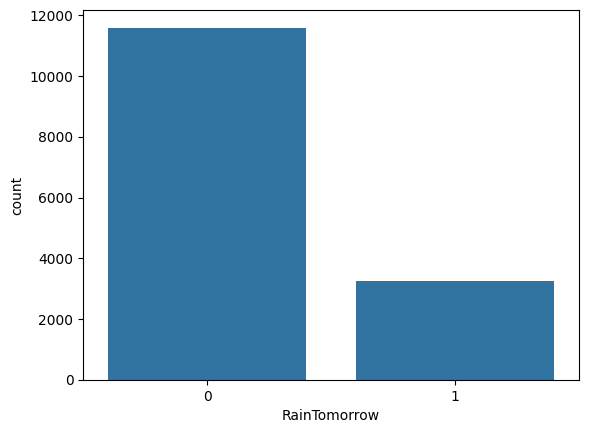

RainTomorrow
0    0.780816
1    0.219184
Name: proportion, dtype: float64


In [114]:
sns.countplot(x=y)
plt.show()

print(y.value_counts(normalize=True))

In [115]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,shuffle=False)


In [116]:
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
print("Ratio:", ratio)

Ratio: 3.553680981595092


In [117]:
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
models={
       "RandomForest": RandomForestClassifier(class_weight='balanced'),
    "AdaBoost": AdaBoostClassifier(),
    "GradientBoost": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(scale_pos_weight=ratio)
}

In [118]:
results={}
trained_modles={}

for name,modle in models.items():
    modle.fit(x_train,y_train)
    y_pred=modle.predict(x_test)

    acu=accuracy_score(y_test,y_pred)
    results[name]=acu
    trained_modles[name]=modle

    print(f"{name}Accuracy:{acu}")

RandomForestAccuracy:0.8101010101010101
AdaBoostAccuracy:0.803030303030303
GradientBoostAccuracy:0.8242424242424242
XGBoostAccuracy:0.7673400673400673


In [119]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import recall_score

tscv = TimeSeriesSplit(n_splits=5)

results = {}
trained_models = {}
recalls = {}


ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

for name, model in models.items():
    
    if name == "RandomForest":
        param_dist = {
            'n_estimators': [100, 200],
            'max_depth': [5, 10]
        }
        
    elif name == "GradientBoost":
        param_dist = {
            'n_estimators': [100, 200],
            'learning_rate': [0.05, 0.1]
        }
        
    elif name == "XGBoost":
        model = XGBClassifier(scale_pos_weight=ratio)  # 🔥 FIX
        
        param_dist = {
            'n_estimators': [200, 300],
            'max_depth': [4, 6],
            'learning_rate': [0.05, 0.1]
        }
        
    else:
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        
        acc = accuracy_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        
        results[name] = acc
        recalls[name] = rec
        trained_models[name] = model
        continue

    search = RandomizedSearchCV(
        model,
        param_distributions=param_dist,
        n_iter=55,                 
        cv=tscv,
        scoring='recall',        
        n_jobs=-1
    )

    search.fit(x_train, y_train)

    best_model = search.best_estimator_
    y_pred = best_model.predict(x_test)

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    results[name] = acc
    recalls[name] = rec
    trained_models[name] = best_model

    print(f"\n{name}")
    print("Best Params:", search.best_params_)
    print("Accuracy:", acc)
    print("Recall:", rec)

c:\Users\anshk\Desktop\ML\ml_env\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 4 is smaller than n_iter=55. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



RandomForest
Best Params: {'n_estimators': 200, 'max_depth': 5}
Accuracy: 0.7356902356902357
Recall: 0.8328173374613003


c:\Users\anshk\Desktop\ML\ml_env\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 4 is smaller than n_iter=55. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



GradientBoost
Best Params: {'n_estimators': 200, 'learning_rate': 0.05}
Accuracy: 0.8272727272727273
Recall: 0.5123839009287926


c:\Users\anshk\Desktop\ML\ml_env\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 8 is smaller than n_iter=55. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



XGBoost
Best Params: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05}
Accuracy: 0.7228956228956229
Recall: 0.8637770897832817


In [122]:
import joblib
joblib.dump(best_model,"xg_model.joblib")

['xg_model.joblib']

In [121]:
# xg boost is selected